# ML profile model factory

This notebook trains column-level anomaly detectors from real tabular datasets, benchmarks several candidate models, selects one champion per data family, and exports ready-to-load artifacts for the application.

The supervision is weak and synthetic on purpose: real column-level anomaly labels are rare, so the notebook injects controlled corruptions to measure how well each detector recovers the anomaly columns. That keeps the workflow aligned with common anomaly-detection practice and with the literature review framing.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

ROOT_DIR = Path('/home/ashahi/PFE/pip/data_quality')
if str(ROOT_DIR) not in sys.path:
    sys.path.insert(0, str(ROOT_DIR))

from settings.config_paths import ML_MODELS_DIR
from orchestration.train_ml_profiles import (
    DEFAULT_CANDIDATE_MODELS,
    DEFAULT_DATASET_SPECS,
    train_and_export,
)

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 140)


## Dataset plan

The current training set covers three families:

- `numeric`: mostly numeric profiles
- `mixed_structured`: structured tabular data with both numeric and categorical fields
- `categorical_text`: categorical and text-heavy tabular data

Protected columns such as identifiers and labels are excluded from anomaly injection and from model training so the detector learns profile quality, not downstream targets.


In [2]:
ARTIFACTS_DIR = ML_MODELS_DIR
DATASET_SPECS = DEFAULT_DATASET_SPECS
CANDIDATE_MODELS = DEFAULT_CANDIDATE_MODELS

ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)
DATASET_SPECS


[DatasetSpec(name='creditcard', path=PosixPath('/home/ashahi/PFE/data/datasets_benchmark2_off/default of credit card clients.xls'), family='numeric', anomaly_rate=0.18, protected_columns=('ID', 'default_payment_next_month')),
 DatasetSpec(name='adult', path=PosixPath('/home/ashahi/PFE/data/datasets_benchmark2_off/adult.data'), family='mixed_structured', anomaly_rate=0.22, protected_columns=('income',)),
 DatasetSpec(name='mushroom', path=PosixPath('/home/ashahi/PFE/data/datasets_benchmark2_off/agaricus-lepiota.data'), family='categorical_text', anomaly_rate=0.18, protected_columns=('class',))]

In [3]:
result = train_and_export(
    dataset_specs=DEFAULT_DATASET_SPECS,
    candidate_models=DEFAULT_CANDIDATE_MODELS,
    output_dir=ARTIFACTS_DIR,
    seeds=range(8),
    max_training_rows=50_000,
)

overall_summary = result['overall_summary']
overall_detail = result['overall_detail']
overall_benchmark = result['overall_benchmark']

display(overall_summary.sort_values(['family', 'f1_mean', 'precision_mean', 'recall_mean'], ascending=[True, False, False, False]))
display(result['champions'])
display(overall_detail.groupby(['family', 'model'], as_index=False).agg(
    f1_mean=('f1', 'mean'),
    f1_std=('f1', 'std'),
    precision_mean=('precision', 'mean'),
    recall_mean=('recall', 'mean'),
    detected_mean=('detected_anomalies', 'mean'),
).sort_values(['family', 'f1_mean'], ascending=[True, False]))
display(overall_benchmark)
print(f"Registry saved to: {result['registry_path']}")
print(f"Summary saved to: {result['summary_path']}")
print(f"Detail saved to: {result['detail_path']}")
print(f"Benchmark saved to: {result['benchmark_path']}")
result['artifact_paths']


26/06/16 17:27:19 WARN Utils: Your hostname, AshLaptop resolves to a loopback address: 127.0.1.1; using 10.255.255.254 instead (on interface lo)
26/06/16 17:27:19 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address


Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


26/06/16 17:27:20 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


/home/ashahi/PFE/env/lib/python3.10/site-packages/sklearn/covariance/_robust_covariance.py:753: UserWarning: The covariance matrix associated to your dataset is not full rank
  warnings.warn(


/home/ashahi/PFE/env/lib/python3.10/site-packages/sklearn/covariance/_robust_covariance.py:753: UserWarning: The covariance matrix associated to your dataset is not full rank
  warnings.warn(


...

,family,model,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,detected_mean,true_anomalies_mean
0,categorical_text,local_outlier_factor,0.718750,0.247758,0.375000,0.188982,0.452083,0.136113,2.375,4.0
1,mixed_structured,local_outlier_factor,0.187500,0.372012,0.083333,0.154303,0.112500,0.210017,0.625,3.0
2,numeric,local_outlier_factor,0.635417,0.208631,0.437500,0.115728,0.513393,0.142494,2.875,4.0


,family,model,f1_mean,f1_std,precision_mean,recall_mean,detected_mean
3,categorical_text,local_outlier_factor,0.452083,0.136113,0.718750,0.375000,2.375
0,categorical_text,elliptic_envelope,0.413690,0.233350,0.479167,0.375000,3.000
1,categorical_text,isolation_forest,0.303571,0.306434,0.395833,0.250000,1.625
2,categorical_text,kmeans,0.100000,0.185164,0.250000,0.062500,0.750
4,categorical_text,one_class_svm,0.000000,0.000000,0.000000,0.000000,0.000
8,mixed_structured,local_outlier_factor,0.112500,0.210017,0.187500,0.083333,0.625
5,mixed_structured,elliptic_envelope,0.083333,0.154303,0.083333,0.083333,2.500
6,mixed_structured,isolation_forest,0.083333,0.154303,0.083333,0.083333,2.000
7,mixed_structured,kmeans,0.000000,0.000000,0.000000,0.000000,0.000
9,mixed_structured,one_class_svm,0.000000,0.000000,0.000000,0.000000,0.000


,dataset_name,family,seed,anomaly_rate,n_columns,n_target_columns,feature_count
0,creditcard,numeric,0,0.18,23,4,26
1,creditcard,numeric,1,0.18,23,4,26
2,creditcard,numeric,2,0.18,23,4,26
3,creditcard,numeric,3,0.18,23,4,26
4,creditcard,numeric,4,0.18,23,4,26
5,creditcard,numeric,5,0.18,23,4,26
6,creditcard,numeric,6,0.18,23,4,26
7,creditcard,numeric,7,0.18,23,4,26
8,adult,mixed_structured,0,0.22,14,3,26
9,adult,mixed_structured,1,0.22,14,3,26


Registry saved to: /home/ashahi/PFE/pip/data_quality/models/ml_profiles/model_registry.json
Summary saved to: /home/ashahi/PFE/pip/data_quality/models/ml_profiles/model_summary.csv
Detail saved to: /home/ashahi/PFE/pip/data_quality/models/ml_profiles/model_detail.csv
Benchmark saved to: /home/ashahi/PFE/pip/data_quality/models/ml_profiles/model_benchmark.csv


{'categorical_text': '/home/ashahi/PFE/pip/data_quality/models/ml_profiles/mushroom_local_outlier_factor_detector.joblib',
 'mixed_structured': '/home/ashahi/PFE/pip/data_quality/models/ml_profiles/adult_local_outlier_factor_detector.joblib',
 'numeric': '/home/ashahi/PFE/pip/data_quality/models/ml_profiles/creditcard_local_outlier_factor_detector.joblib'}

## Results snapshot

This section reloads the exported registry and benchmark tables so the notebook always shows the official training outcome, even when you revisit it later.


,family,dataset_name,model_name,artifact_path,protected_columns,anomaly_rate,metrics
0,categorical_text,mushroom,local_outlier_factor,/home/ashahi/PFE/pip/data_quality/models/ml_pr...,[class],0.18,"{'family': 'categorical_text', 'model': 'local..."
1,mixed_structured,adult,local_outlier_factor,/home/ashahi/PFE/pip/data_quality/models/ml_pr...,[income],0.22,"{'family': 'mixed_structured', 'model': 'local..."
2,numeric,creditcard,local_outlier_factor,/home/ashahi/PFE/pip/data_quality/models/ml_pr...,"[ID, default_payment_next_month]",0.18,"{'family': 'numeric', 'model': 'local_outlier_..."


,family,model,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,detected_mean,true_anomalies_mean
10,categorical_text,local_outlier_factor,0.718750,0.247758,0.375000,0.188982,0.452083,0.136113,2.375,4.0
11,categorical_text,elliptic_envelope,0.479167,0.247006,0.375000,0.231455,0.413690,0.233350,3.000,4.0
12,categorical_text,isolation_forest,0.395833,0.366640,0.250000,0.267261,0.303571,0.306434,1.625,4.0
13,categorical_text,kmeans,0.250000,0.462910,0.062500,0.115728,0.100000,0.185164,0.750,4.0
14,categorical_text,one_class_svm,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000,4.0
5,mixed_structured,local_outlier_factor,0.187500,0.372012,0.083333,0.154303,0.112500,0.210017,0.625,3.0
6,mixed_structured,elliptic_envelope,0.083333,0.154303,0.083333,0.154303,0.083333,0.154303,2.500,3.0
7,mixed_structured,isolation_forest,0.083333,0.154303,0.083333,0.154303,0.083333,0.154303,2.000,3.0
8,mixed_structured,kmeans,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000,3.0
9,mixed_structured,one_class_svm,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000,3.0


,family,model,f1_mean,precision_mean,recall_mean,detected_mean,true_anomalies_mean
3,categorical_text,local_outlier_factor,0.452083,0.718750,0.375000,2.375,4.0
0,categorical_text,elliptic_envelope,0.413690,0.479167,0.375000,3.000,4.0
1,categorical_text,isolation_forest,0.303571,0.395833,0.250000,1.625,4.0
2,categorical_text,kmeans,0.100000,0.250000,0.062500,0.750,4.0
4,categorical_text,one_class_svm,0.000000,0.000000,0.000000,0.000,4.0
8,mixed_structured,local_outlier_factor,0.112500,0.187500,0.083333,0.625,3.0
5,mixed_structured,elliptic_envelope,0.083333,0.083333,0.083333,2.500,3.0
6,mixed_structured,isolation_forest,0.083333,0.083333,0.083333,2.000,3.0
7,mixed_structured,kmeans,0.000000,0.000000,0.000000,0.000,3.0
9,mixed_structured,one_class_svm,0.000000,0.000000,0.000000,0.000,3.0


,dataset_name,family,seed,anomaly_rate,n_columns,n_target_columns,feature_count
0,creditcard,numeric,0,0.18,23,4,26
1,creditcard,numeric,1,0.18,23,4,26
2,creditcard,numeric,2,0.18,23,4,26
3,creditcard,numeric,3,0.18,23,4,26
4,creditcard,numeric,4,0.18,23,4,26
5,creditcard,numeric,5,0.18,23,4,26
6,creditcard,numeric,6,0.18,23,4,26
7,creditcard,numeric,7,0.18,23,4,26
8,adult,mixed_structured,0,0.22,14,3,26
9,adult,mixed_structured,1,0.22,14,3,26


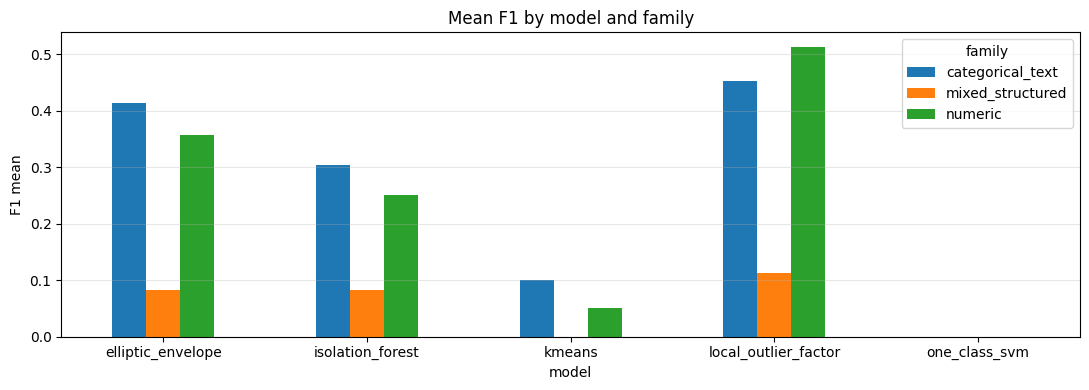

,family,model,f1_mean,precision_mean,recall_mean
10,categorical_text,local_outlier_factor,0.452083,0.718750,0.375000
5,mixed_structured,local_outlier_factor,0.112500,0.187500,0.083333
0,numeric,local_outlier_factor,0.513393,0.635417,0.437500


Takeaway: the notebook now keeps the official benchmark snapshot inline, so the report can cite the same values as the exported registry.


In [4]:
import json

registry_path = Path(result['registry_path'])
summary_path = Path(result['summary_path'])
detail_path = Path(result['detail_path'])
benchmark_path = Path(result['benchmark_path'])

with registry_path.open('r', encoding='utf-8') as fh:
    registry = json.load(fh)

summary_df = pd.read_csv(summary_path)
detail_df = pd.read_csv(detail_path)
benchmark_df = pd.read_csv(benchmark_path)

display(pd.DataFrame(registry['families']))
display(summary_df.sort_values(['family', 'f1_mean', 'precision_mean', 'recall_mean'], ascending=[True, False, False, False]))
display(detail_df.groupby(['family', 'model'], as_index=False).agg(
    f1_mean=('f1', 'mean'),
    precision_mean=('precision', 'mean'),
    recall_mean=('recall', 'mean'),
    detected_mean=('detected_anomalies', 'mean'),
    true_anomalies_mean=('true_anomalies', 'mean'),
).sort_values(['family', 'f1_mean'], ascending=[True, False]))
display(benchmark_df)

pivot = summary_df.pivot_table(index='model', columns='family', values='f1_mean', aggfunc='mean')
ax = pivot.plot(kind='bar', figsize=(11, 4), rot=0)
ax.set_title('Mean F1 by model and family')
ax.set_ylabel('F1 mean')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

top = summary_df.sort_values(['family', 'f1_mean'], ascending=[True, False]).groupby('family', as_index=False).head(1)
display(top[['family', 'model', 'f1_mean', 'precision_mean', 'recall_mean']])

print('Takeaway: the notebook now keeps the official benchmark snapshot inline, so the report can cite the same values as the exported registry.')


In [5]:
# L'entraînement utilise les modules dans `orchestration/`.
# Le notebook reste une surface de lancement et d'affichage.
display(result['champions'])
result['artifact_paths']


,family,model,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,detected_mean,true_anomalies_mean
0,categorical_text,local_outlier_factor,0.718750,0.247758,0.375000,0.188982,0.452083,0.136113,2.375,4.0
1,mixed_structured,local_outlier_factor,0.187500,0.372012,0.083333,0.154303,0.112500,0.210017,0.625,3.0
2,numeric,local_outlier_factor,0.635417,0.208631,0.437500,0.115728,0.513393,0.142494,2.875,4.0


{'categorical_text': '/home/ashahi/PFE/pip/data_quality/models/ml_profiles/mushroom_local_outlier_factor_detector.joblib',
 'mixed_structured': '/home/ashahi/PFE/pip/data_quality/models/ml_profiles/adult_local_outlier_factor_detector.joblib',
 'numeric': '/home/ashahi/PFE/pip/data_quality/models/ml_profiles/creditcard_local_outlier_factor_detector.joblib'}

## What this notebook gives you

- one champion detector per dataset family
- serialized artifacts ready for backend loading
- a registry file with metadata, chosen model names, and protected columns
- benchmark tables that you can cite in the literature review section to justify the hybrid approach

Next step in the application: load the family artifact during validation, run inference on the profiled columns, and merge its signal with the rule-based outputs from Deequ, Great Expectations, and Spark validators.
